source: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

In [1]:
# Core scverse libraries
import scanpy as sc
import anndata as ad

import os

#sc.settings.set_figure_params(dpi=50, facecolor="white")

In [3]:
adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592055_M8.h5ad"))
print(adata.obs["Sample_ID"].value_counts())
adata

Sample_ID
CL-like2    4992
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

# Quality Control

In [4]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.upper().str.contains("^HB[^(P)]")

In [5]:
print(f"Mitochondrial genes: {round(adata.var['mt'].sum()/adata.n_vars *100, 1)}%")
print(f"Ribosomal genes: {round(adata.var['ribo'].sum()/adata.n_vars *100, 1)}%")
print(f"Hemoglobin genes: {round(adata.var['hb'].sum()/adata.n_vars *100, 1)}%")

Mitochondrial genes: 0.0%
Ribosomal genes: 0.3%
Hemoglobin genes: 0.0%


In [6]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

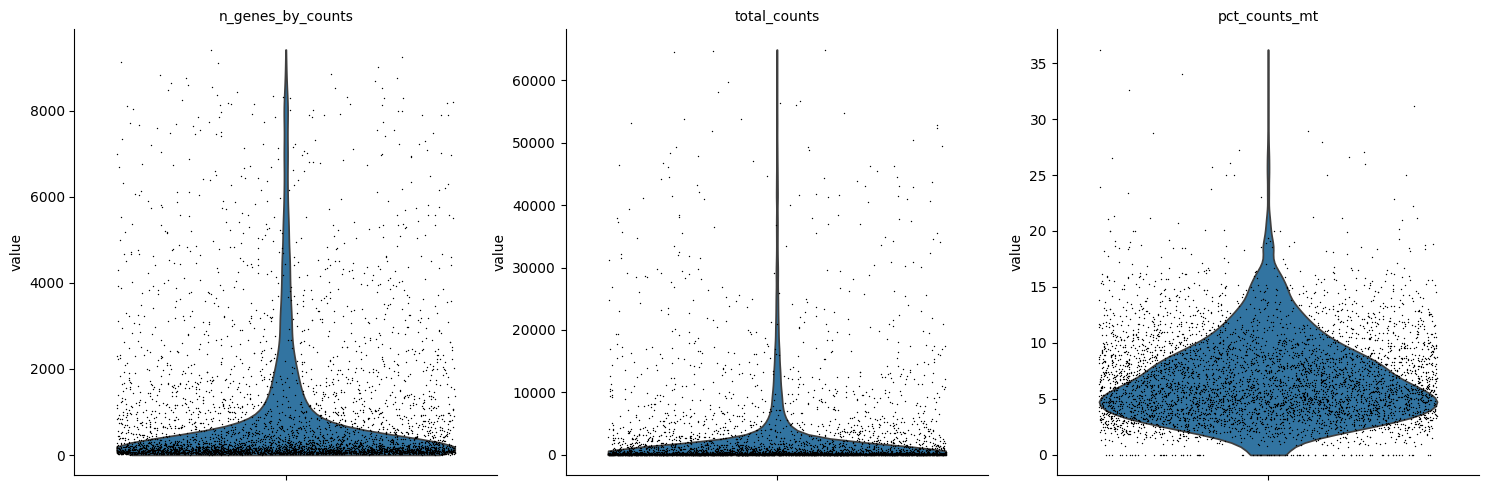

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

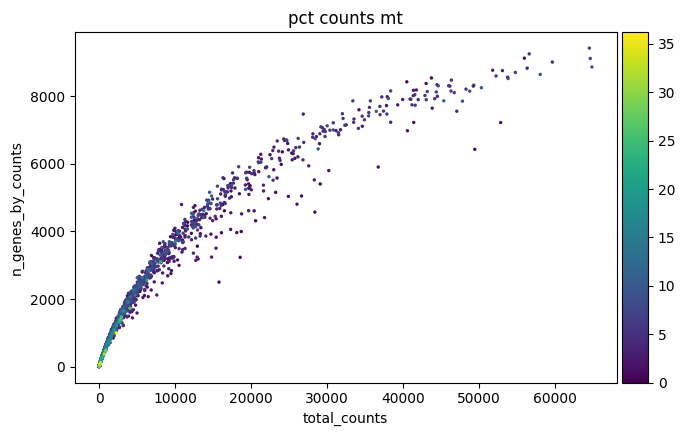

In [8]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [9]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

# Doublet Detection

In [10]:
sc.pp.scrublet(adata)

In [11]:
print(adata.obs["predicted_doublet"].sum())

1


# Normalization

In [12]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalizing to 1e4 total counts
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

# Feature selection

In [13]:
adata.n_vars

19095

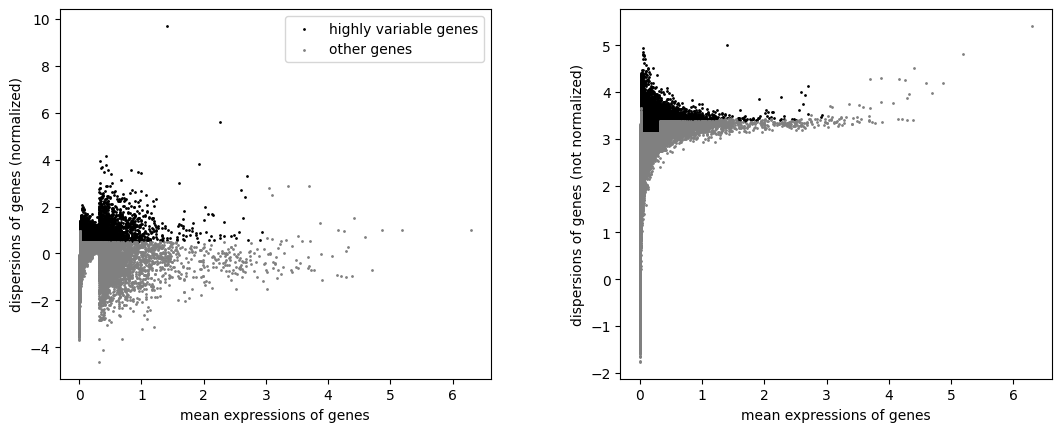

In [14]:
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

# Dimensionality Reduction

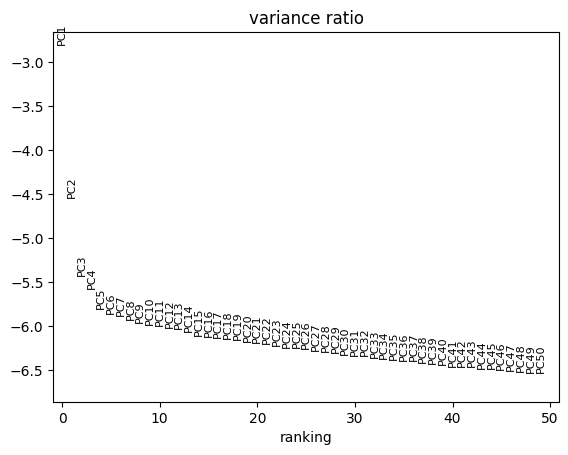

In [15]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

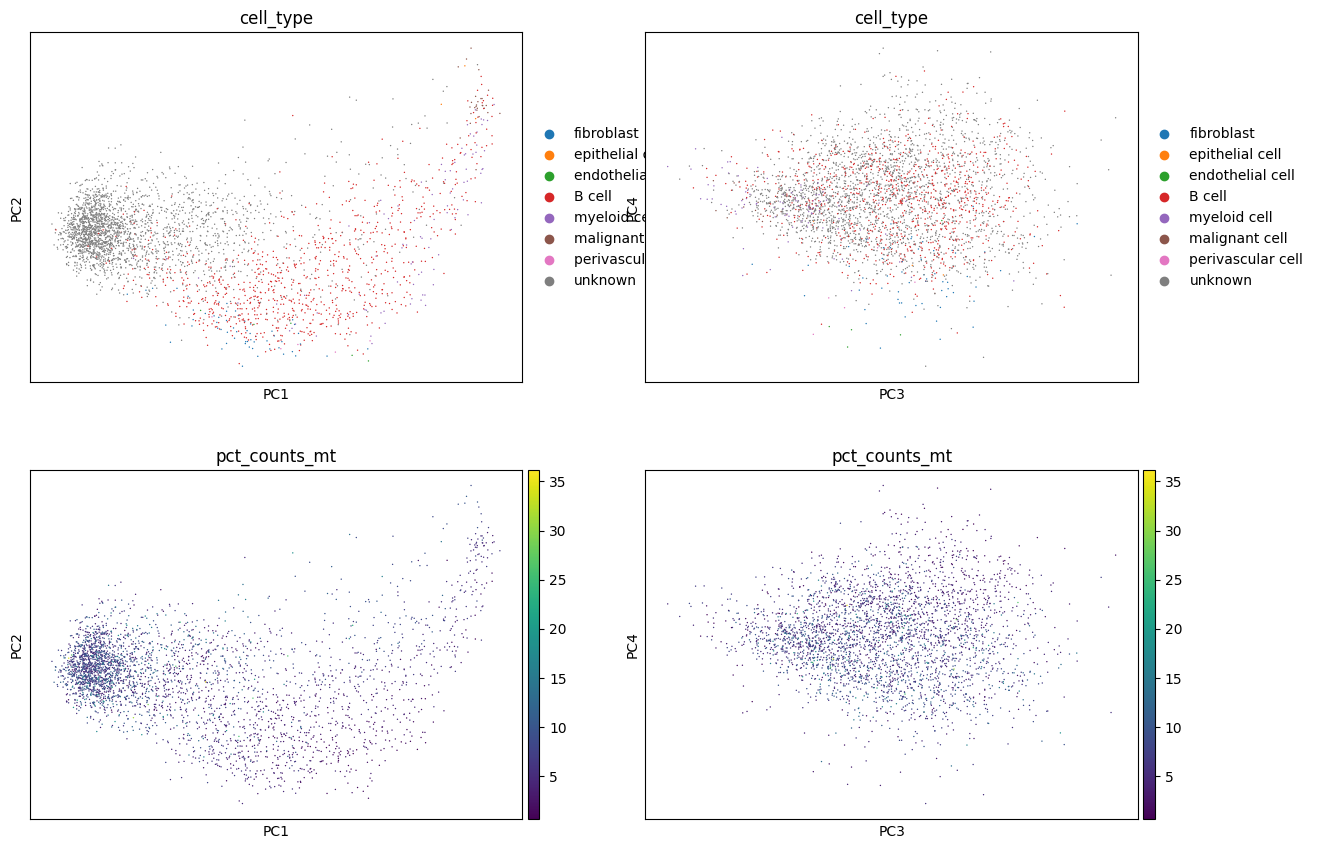

In [16]:
sc.pl.pca(
    adata,
    color=["cell_type", "cell_type", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=4,
)

# Nearest neighbor graph construction and visualization

In [17]:
sc.pp.neighbors(adata)

c:\Users\rebec\miniforge3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


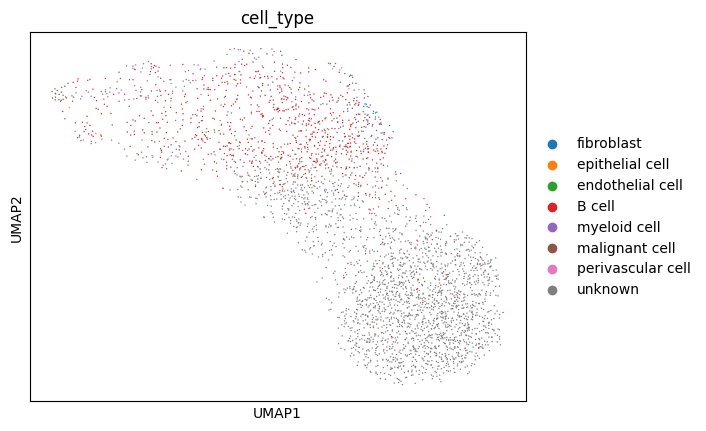

In [18]:
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="cell_type",
    # Setting a smaller point size to get prevent overlap
    size=4,
)

# Clustering

Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 794, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 2881, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 794, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 2881, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (most recent call last):
  File "numpy\\random\\mtrand.pyx", line 794, in numpy.random.mtrand.RandomState.randint
  File "numpy\\random\\_bounded_integers.pyx", line 2881, in numpy.random._bounded_integers._rand_int32
ValueError: high is out of bounds for int32
Exception ignored in: <class 'ValueError'>
Traceback (m

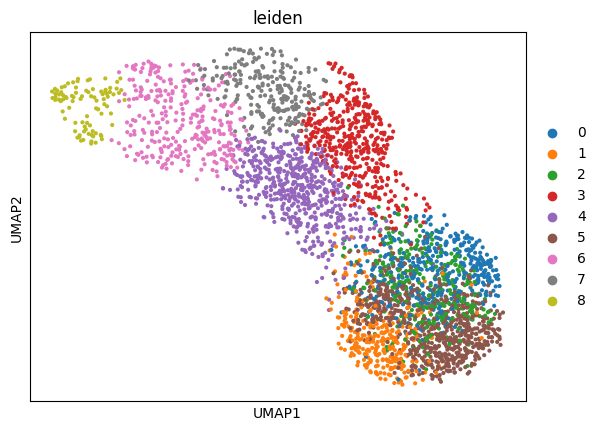

In [22]:
import numpy as np
np.random.seed(1)

# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, color=["leiden"])

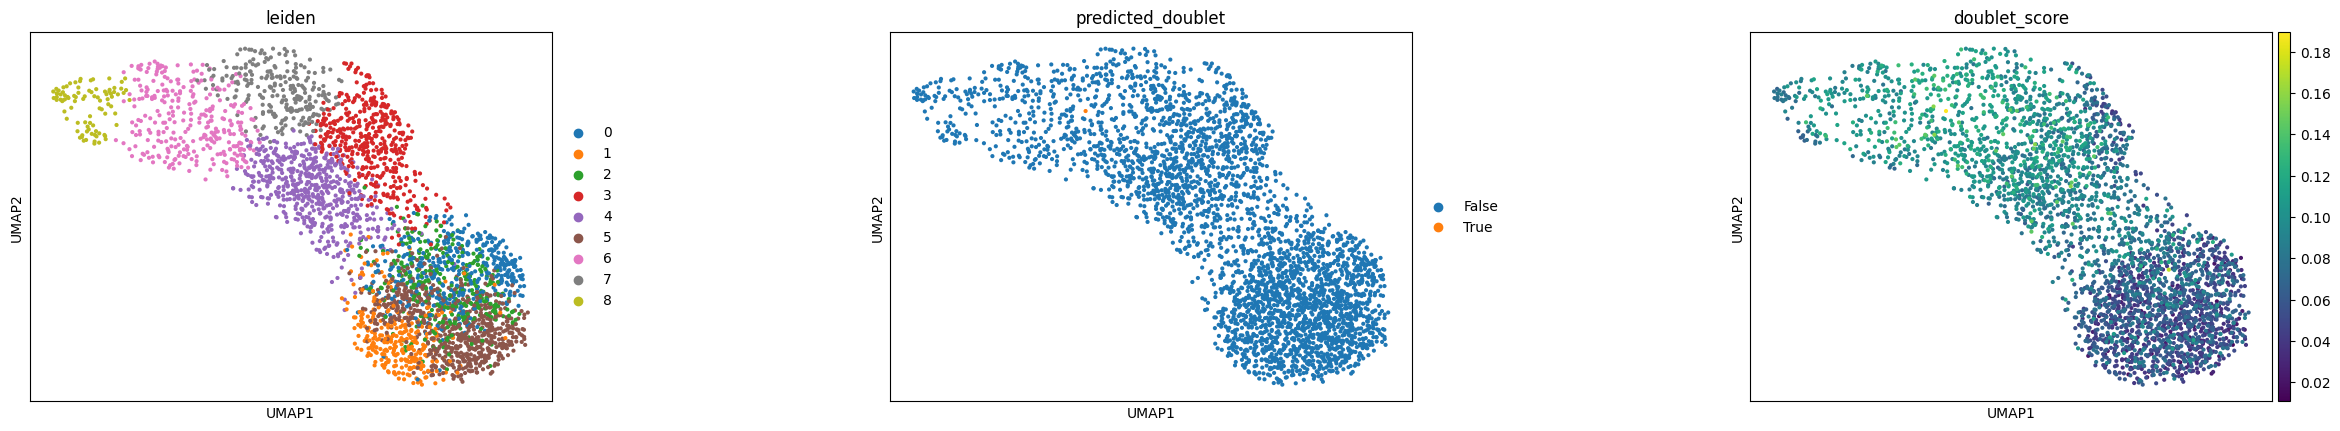

In [25]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
)

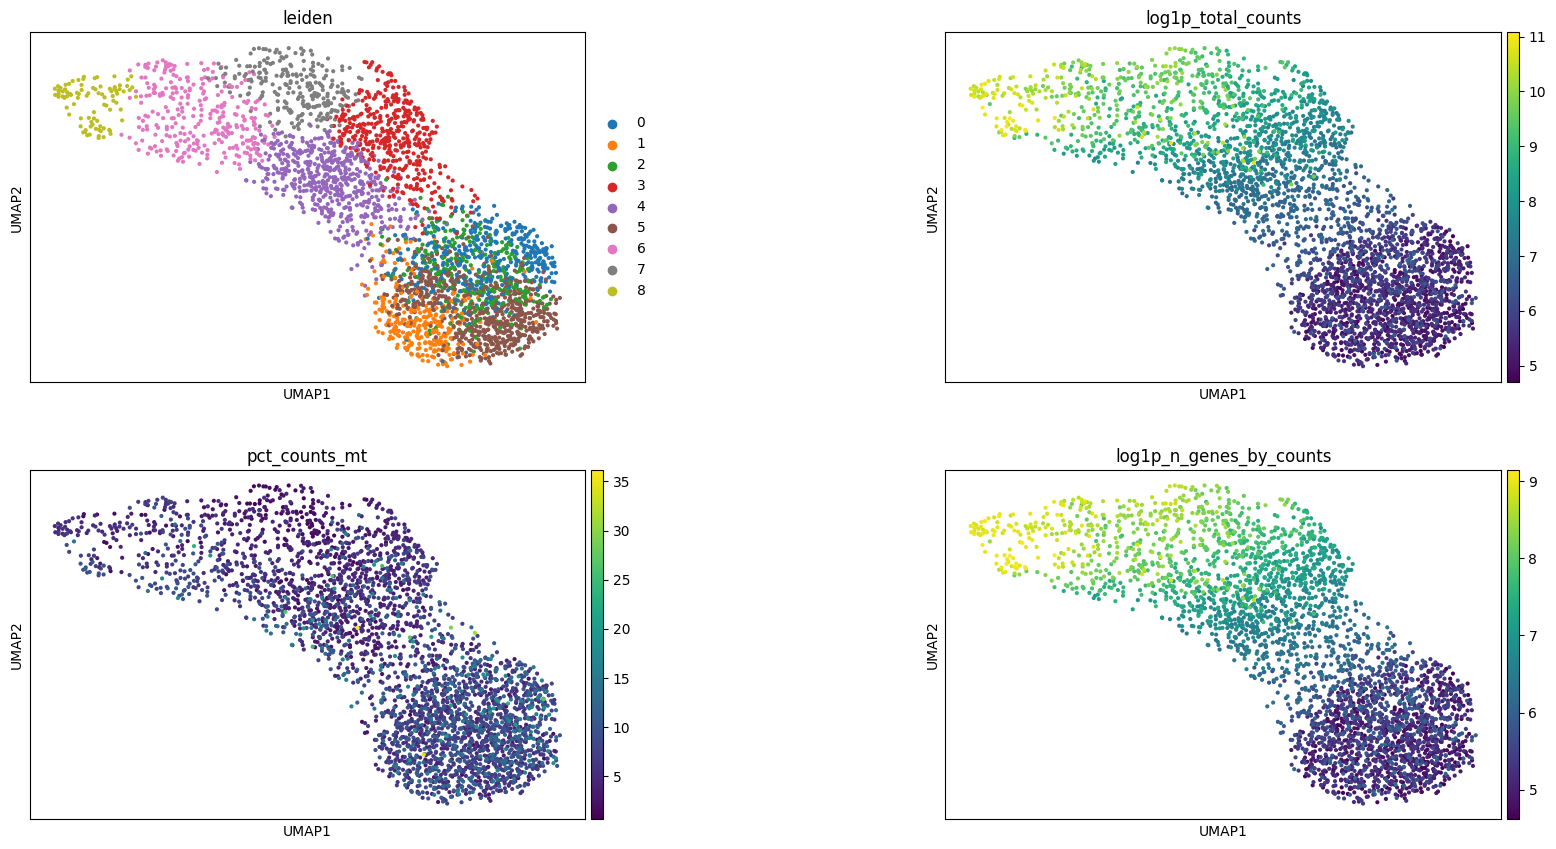

In [24]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)